In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional-looking charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Cell 2: Load Data
# Using relative path to access the kaggle_data directory
data_path = '../data/kaggle_data/train.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 1460 rows and 81 columns.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


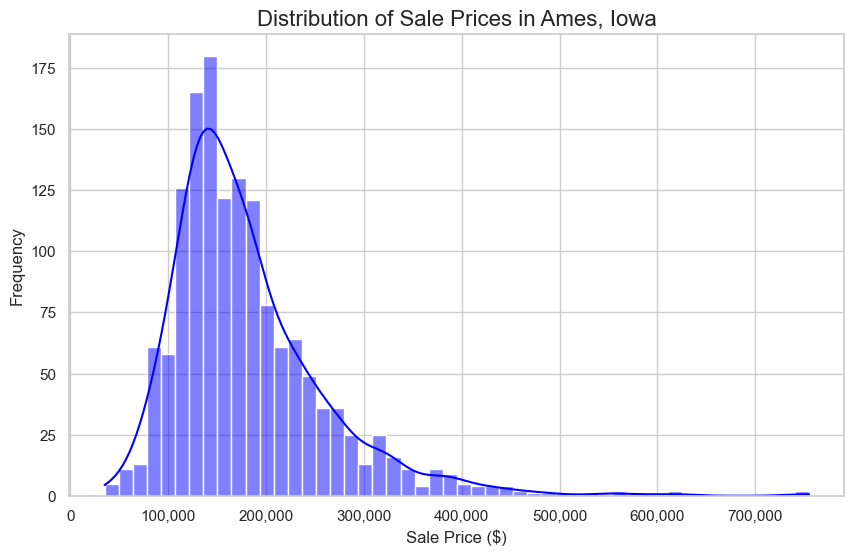

In [3]:
# Cell 3: SalePrice Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of Sale Prices in Ames, Iowa', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Format x-axis with dollar signs and commas
formatter = plt.FuncFormatter(lambda x, p: format(int(x), ','))
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()

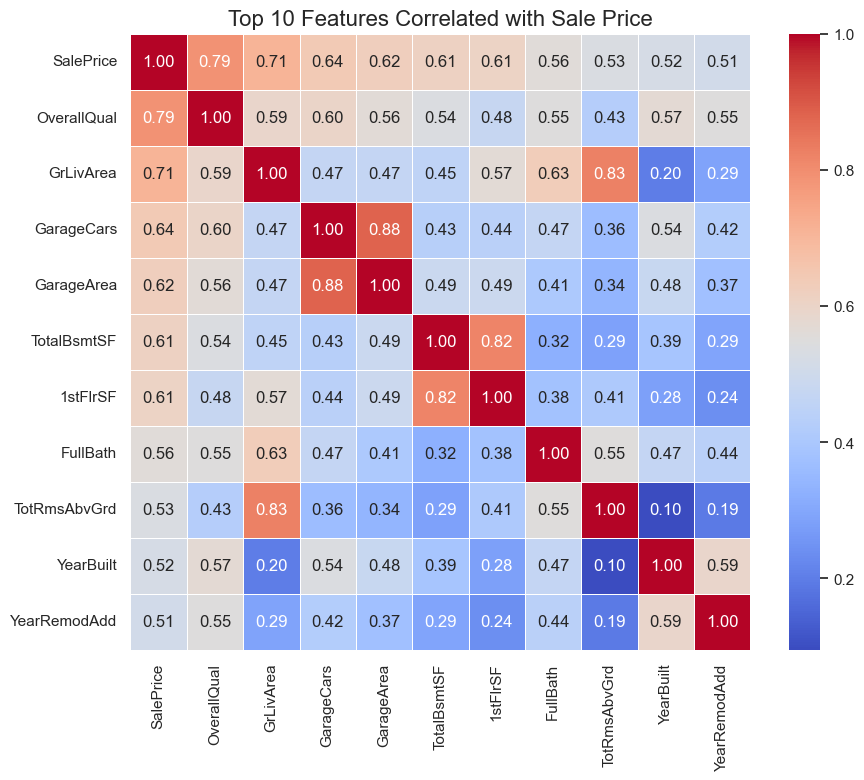

In [4]:
# Cell 4: Correlation Heatmap (Top 10 Features)
# Filter for numerical columns only to avoid errors
numeric_df = df.select_dtypes(include=[np.number])

# Find the top 10 numerical features most highly correlated with SalePrice
top_corr_features = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(11).index
top_corr_matrix = df[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Top 10 Features Correlated with Sale Price', fontsize=16)
plt.show()

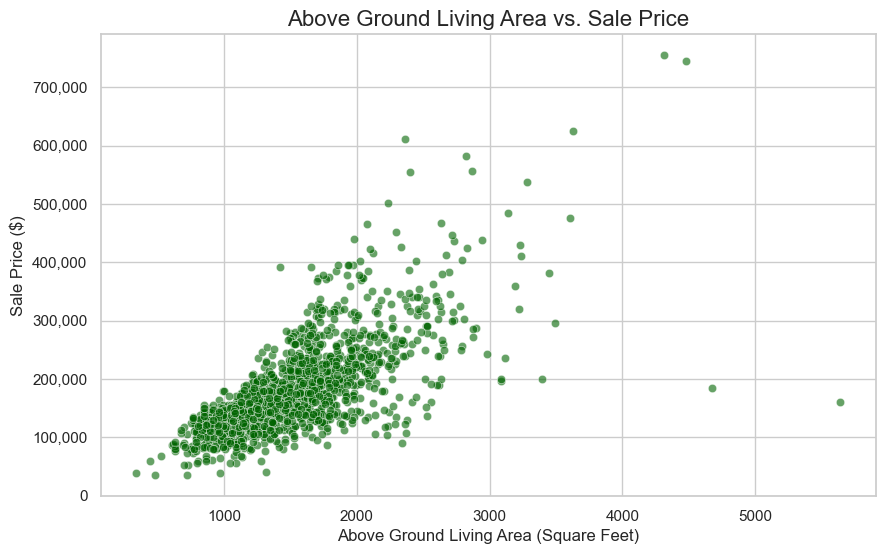

In [5]:
# Cell 5: Living Area vs. Sale Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.6, color='darkgreen')

plt.title('Above Ground Living Area vs. Sale Price', fontsize=16)
plt.xlabel('Above Ground Living Area (Square Feet)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)

# Format y-axis with dollar signs
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()